# Diabetic Retinopathy Severity Grading
**Models:** Custom CNN | ResNet50 | MobileNetV2  
**Dataset:** APTOS 2019 Blindness Detection  
**Task:** 5-Class Severity Grading (Grade 0–4)  
**Framework:** TensorFlow / Keras

## 1. Imports & Configuration

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR    = '/kaggle/input/competitions/aptos2019-blindness-detection'
TRAIN_CSV   = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG   = os.path.join(DATA_DIR, 'train_images')
FIGURES_DIR = '/kaggle/working/figures'
TABLES_DIR  = '/kaggle/working/tables'
MODEL_DIR   = '/kaggle/working/models'
OUTPUT_DIR  = FIGURES_DIR
for d in [FIGURES_DIR, TABLES_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE_CNN   = 224
IMG_SIZE_TL    = 224
BATCH_SIZE     = 32
EPOCHS_CNN     = 30
EPOCHS_TL      = 20
NUM_CLASSES    = 5
LR_CNN         = 1e-4
LR_TL_FREEZE   = 1e-3
LR_TL_FINETUNE = 1e-5
CLASS_NAMES    = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
CLASS_LABELS   = [0, 1, 2, 3, 4]

print('Project: Diabetic Retinopathy Severity Grading')
print('Models: Custom CNN, ResNet50, MobileNetV2')
print(f'Data path exists: {os.path.exists(DATA_DIR)}')
print('Configuration ready')

2026-06-07 08:51:59.014947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780822319.400689      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780822319.517586      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780822320.531903      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780822320.531944      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780822320.531947      58 computation_placer.cc:177] computation placer alr

Project: Diabetic Retinopathy Severity Grading
Models: Custom CNN, ResNet50, MobileNetV2
Data path exists: True
Configuration ready


## 2. Dataset Loading & EDA

Total images: 3662
  Grade 0 (No DR): 1805 (49.3%)
  Grade 1 (Mild): 370 (10.1%)
  Grade 2 (Moderate): 999 (27.3%)
  Grade 3 (Severe): 193 (5.3%)
  Grade 4 (Proliferative DR): 295 (8.1%)


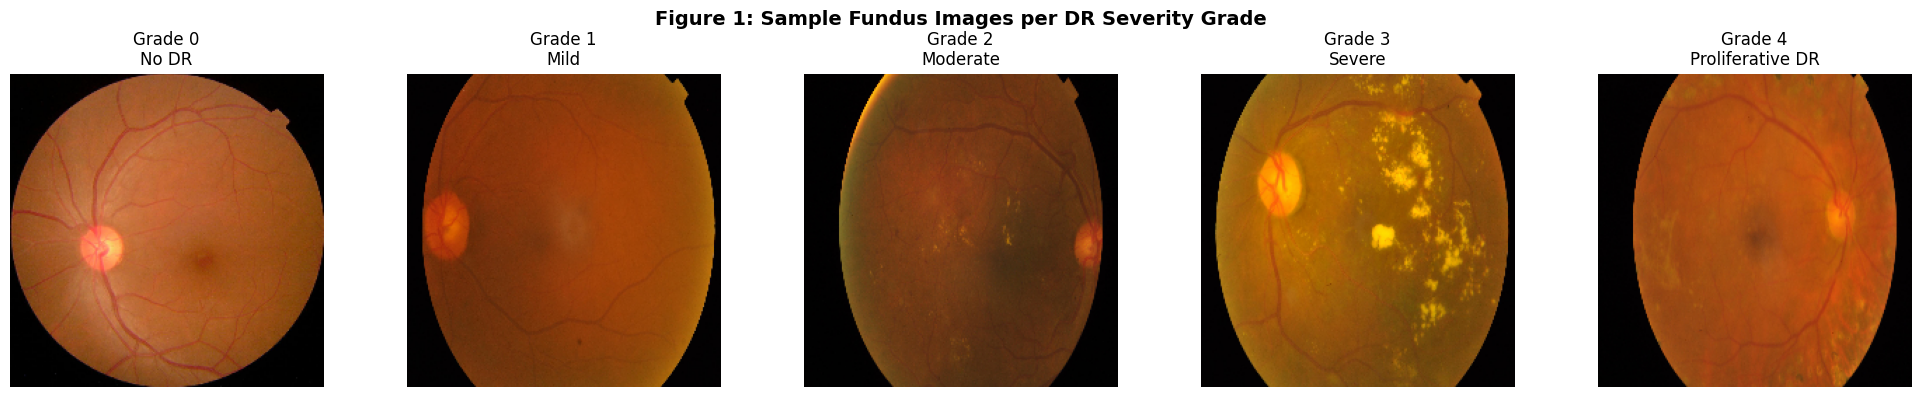

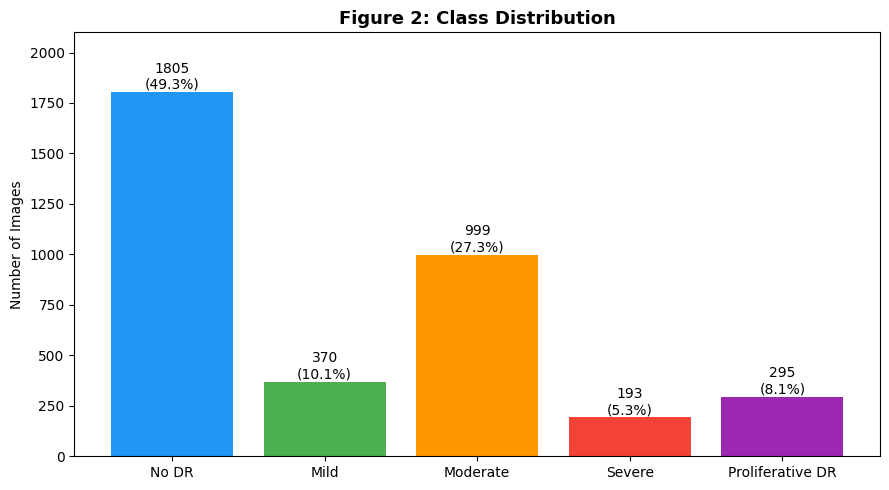

In [2]:
df = pd.read_csv(TRAIN_CSV)
df['filepath'] = df['id_code'].apply(lambda x: os.path.join(TRAIN_IMG, x + '.png'))

print(f'Total images: {len(df)}')
dist = df['diagnosis'].value_counts().sort_index()
for grade, count in dist.items():
    print(f'  Grade {grade} ({CLASS_NAMES[grade]}): {count} ({100*count/len(df):.1f}%)')

pd.DataFrame({
    'Grade': CLASS_LABELS, 'Label': CLASS_NAMES,
    'Image_Count': [dist.get(g, 0) for g in CLASS_LABELS],
    'Percentage': [f'{100*dist.get(g,0)/len(df):.1f}%' for g in CLASS_LABELS],
}).to_csv(os.path.join(TABLES_DIR, 'table1_class_distribution.csv'), index=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Figure 1: Sample Fundus Images per DR Severity Grade', fontsize=14, fontweight='bold')
for grade in range(5):
    img = cv2.imread(df[df['diagnosis'] == grade]['filepath'].iloc[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    axes[grade].imshow(img)
    axes[grade].set_title(f'Grade {grade}\n{CLASS_NAMES[grade]}')
    axes[grade].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_sample_images.pdf'), dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, dist.values, color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'])
for bar, count in zip(bars, dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
            f'{count}\n({100*count/len(df):.1f}%)', ha='center', fontsize=10)
ax.set_title('Figure 2: Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images'); ax.set_ylim(0, 2100)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_class_distribution.pdf'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing & Dataset Split

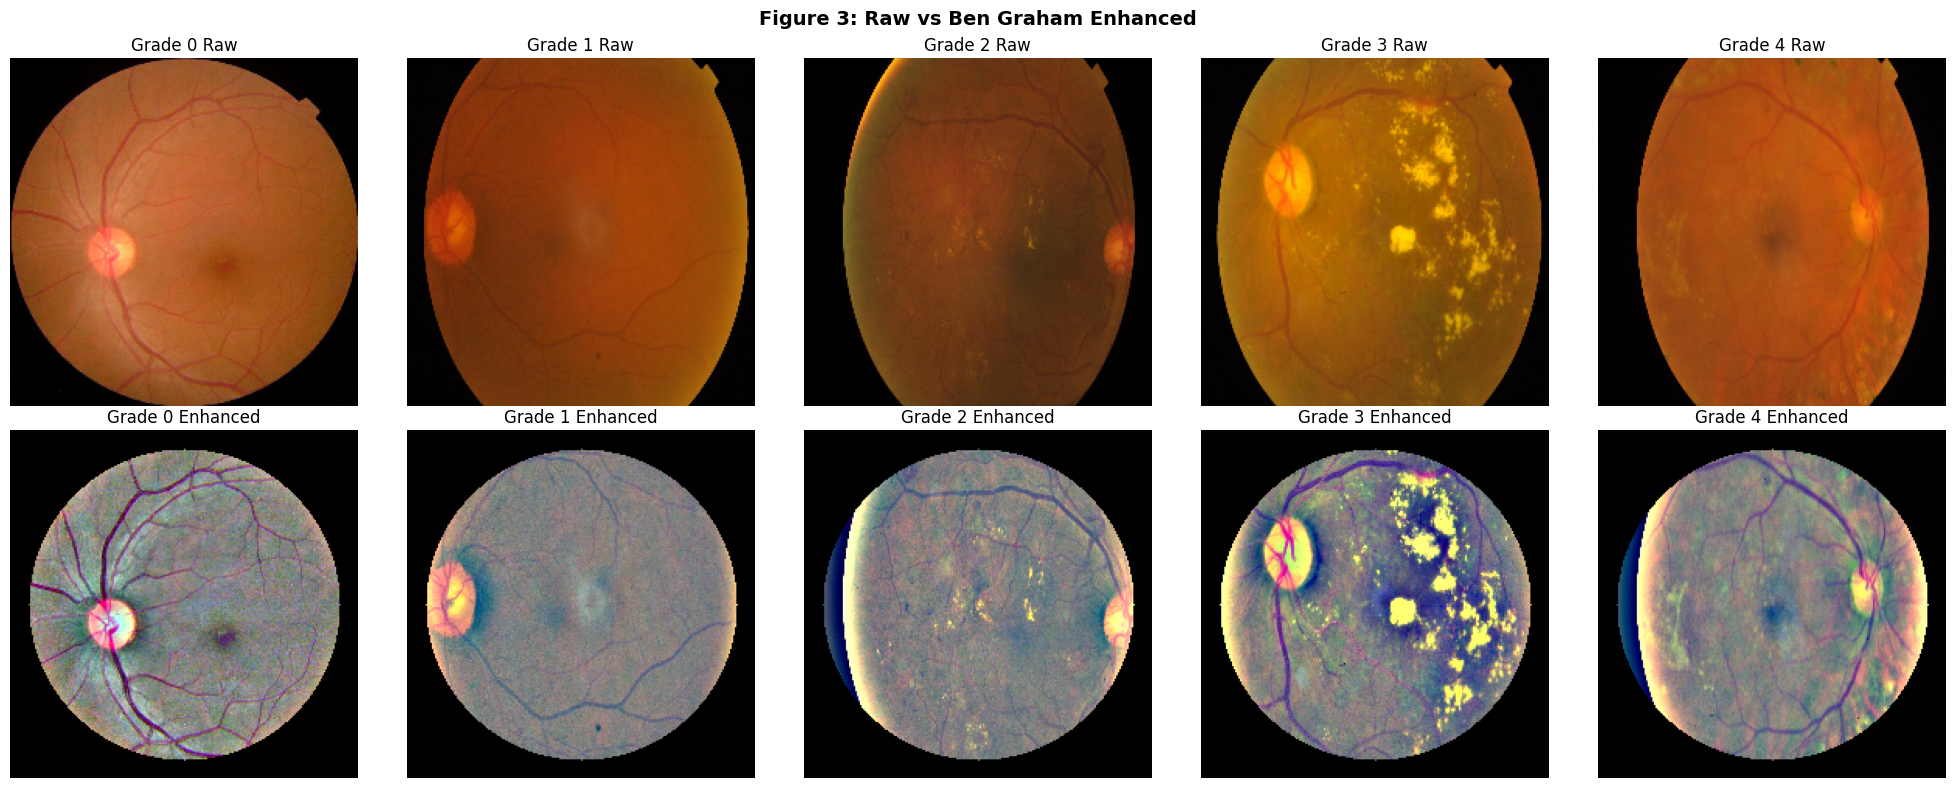

Train: 2929 | Val: 366 | Test: 367
Split saved


In [3]:
def ben_graham_preprocessing(img_path, img_size=224, sigmaX=10):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigmaX)
    enhanced = cv2.addWeighted(img, 4, blur, -4, 128)
    mask = np.zeros(enhanced.shape)
    cv2.circle(mask, (img_size//2, img_size//2), int(img_size*0.45), (1,1,1), -1)
    return (enhanced * mask).astype(np.uint8)

def load_and_preprocess(img_path, img_size=224, use_ben_graham=False):
    if use_ben_graham:
        img = ben_graham_preprocessing(img_path, img_size)
    else:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
    return img.astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Figure 3: Raw vs Ben Graham Enhanced', fontsize=14, fontweight='bold')
for grade in range(5):
    sp = df[df['diagnosis'] == grade]['filepath'].iloc[0]
    raw = cv2.cvtColor(cv2.imread(sp), cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (224, 224))
    axes[0, grade].imshow(raw); axes[0, grade].set_title(f'Grade {grade} Raw'); axes[0, grade].axis('off')
    axes[1, grade].imshow(ben_graham_preprocessing(sp)); axes[1, grade].set_title(f'Grade {grade} Enhanced'); axes[1, grade].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_preprocessing.pdf'), dpi=150, bbox_inches='tight')
plt.show()

train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df['diagnosis'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['diagnosis'], random_state=SEED)
train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
for s in [train_df, val_df, test_df]:
    s['diagnosis'] = s['diagnosis'].astype(str)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
pd.DataFrame([{'Grade': g, 'Label': CLASS_NAMES[g],
    'Train': (train_df['diagnosis'].astype(int)==g).sum(),
    'Val': (val_df['diagnosis'].astype(int)==g).sum(),
    'Test': (test_df['diagnosis'].astype(int)==g).sum(),
} for g in CLASS_LABELS]).to_csv(os.path.join(TABLES_DIR, 'table2_dataset_split.csv'), index=False)
print('Split saved')

## 4. Data Augmentation & Generators

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255, horizontal_flip=True, vertical_flip=True,
    rotation_range=20, zoom_range=0.10,
    width_shift_range=0.10, height_shift_range=0.10,
    brightness_range=[0.85, 1.15], fill_mode='reflect',
)
val_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, img_size, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe, x_col='filepath', y_col='diagnosis',
        target_size=(img_size, img_size), color_mode='rgb',
        class_mode='categorical', batch_size=BATCH_SIZE,
        shuffle=shuffle, seed=SEED,
    )

train_gen = make_gen(train_datagen, train_df, IMG_SIZE_CNN, shuffle=True)
val_gen   = make_gen(val_datagen,   val_df,   IMG_SIZE_CNN, shuffle=False)
test_gen  = make_gen(val_datagen,   test_df,  IMG_SIZE_CNN, shuffle=False)
train_gen_tl = make_gen(train_datagen, train_df, IMG_SIZE_TL, shuffle=True)
val_gen_tl   = make_gen(val_datagen,   val_df,   IMG_SIZE_TL, shuffle=False)
test_gen_tl  = make_gen(val_datagen,   test_df,  IMG_SIZE_TL, shuffle=False)

labels_int = train_df['diagnosis'].astype(int).values
cw_array = compute_class_weight('balanced', classes=np.array(CLASS_LABELS), y=labels_int)
class_weight_dict = {i: w for i, w in enumerate(cw_array)}
print('Class weights:', {k: f'{v:.2f}' for k, v in class_weight_dict.items()})
print('Generators ready')

Found 2929 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.
Found 2929 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.
Class weights: {0: '0.41', 1: '1.98', 2: '0.73', 3: '3.80', 4: '2.48'}
Generators ready


## 5. Custom CNN Architecture & Training

In [5]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=5):
    inputs = keras.Input(shape=input_shape, name='input_layer')
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)
        return x
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 512)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return Model(inputs, outputs, name='Custom_CNN_DR')

custom_cnn = build_custom_cnn()
custom_cnn.summary()
custom_cnn.compile(optimizer=keras.optimizers.Adam(LR_CNN),
                   loss='categorical_crossentropy', metrics=['accuracy'])

print('Training Custom CNN...')
history_cnn = custom_cnn.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_CNN, class_weight=class_weight_dict,
    callbacks=[
        ModelCheckpoint(os.path.join(MODEL_DIR, 'custom_cnn_best.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ], verbose=1,
)
print('Custom CNN training complete')

I0000 00:00:1780822359.042737      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780822359.048637      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN_DR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 1,839,813 (7.02 MB)

 Trainable params: 1,836,805 (7.01 MB)

...

Training Custom CNN...
Epoch 1/30


I0000 00:00:1780822380.137368     137 service.cc:152] XLA service 0x7b90fc007690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780822380.137415     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780822380.137421     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780822381.052901     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/92 ━━━━━━━━━━━━━━━━━━━━ 28:53 19s/step - accuracy: 0.1875 - loss: 2.9303

I0000 00:00:1780822390.663478     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3634 - loss: 2.0508
Epoch 1: val_accuracy improved from None to 0.10109, saving model to /kaggle/working/models/custom_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/models/custom_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 485s 5s/step - accuracy: 0.3974 - loss: 1.9842 - val_accuracy: 0.1011 - val_loss: 1.9935 - learning_rate: 1.0000e-04
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4725 - loss: 1.8692
Epoch 2: val_accuracy did not improve from 0.10109
92/92 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.4677 - loss: 1.8547 - val_accuracy: 0.1011 - val_loss: 2.3156 - learning_rate: 1.0000e-04
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4903 - loss: 1.7342
Epoch 3: val_accuracy did not improve from 0.10109
92/92 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.4954 - loss: 1.6851 - val_accuracy: 0.1011 - val_loss: 2.7797 - learning_rate: 1.0000e-04
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━

## 6. Transfer Learning — ResNet50

In [6]:
def build_resnet50(input_shape=(224, 224, 3), num_classes=5):
    base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='ResNet50_DR'), base

resnet_model, resnet_base = build_resnet50()
resnet_model.compile(optimizer=keras.optimizers.Adam(LR_TL_FREEZE),
                     loss='categorical_crossentropy', metrics=['accuracy'])

print('Phase 1: Training ResNet50 head...')
resnet_model.fit(train_gen_tl, validation_data=val_gen_tl, epochs=8,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)], verbose=1)

print('Phase 2: Fine-tuning ResNet50...')
for layer in resnet_base.layers:
    if 'conv4' in layer.name or 'conv5' in layer.name:
        layer.trainable = True
resnet_model.compile(optimizer=keras.optimizers.Adam(LR_TL_FINETUNE),
                     loss='categorical_crossentropy', metrics=['accuracy'])
history_res = resnet_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=EPOCHS_TL, class_weight=class_weight_dict,
    callbacks=[
        ModelCheckpoint(os.path.join(MODEL_DIR, 'resnet50_best.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ], verbose=1,
)
print('ResNet50 training complete')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training ResNet50 head...
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.4575 - loss: 1.4831 - val_accuracy: 0.4918 - val_loss: 1.8236 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.4896 - loss: 1.4776 - val_accuracy: 0.4918 - val_loss: 1.5632 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.4985 - loss: 1.4565 - val_accuracy: 0.2732 - val_loss: 3.9151 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.5230 - loss: 1.4131 - val_accuracy: 0.1339 - val_loss: 1.7322 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.5258 - loss: 1.3460 - val_accuracy: 0.1393 - val_loss: 2.5055 - learning_rate: 5.0000e-04
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.5524 - loss: 1.3146 - val_accuracy: 0.0546 - val_loss: 8.8201 - learning_rate: 5.0000e-04
Phase 

## 7. Transfer Learning — MobileNetV2

In [7]:
def build_mobilenetv2(input_shape=(224, 224, 3), num_classes=5):
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='MobileNetV2_DR'), base

mobilenet_model, mobilenet_base = build_mobilenetv2()
mobilenet_model.compile(optimizer=keras.optimizers.Adam(LR_TL_FREEZE),
                        loss='categorical_crossentropy', metrics=['accuracy'])

print('Phase 1: Training MobileNetV2 head...')
mobilenet_model.fit(train_gen_tl, validation_data=val_gen_tl, epochs=8,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)], verbose=1)

print('Phase 2: Fine-tuning MobileNetV2...')
for layer in mobilenet_base.layers[int(len(mobilenet_base.layers)*0.70):]:
    layer.trainable = True
mobilenet_model.compile(optimizer=keras.optimizers.Adam(LR_TL_FINETUNE),
                        loss='categorical_crossentropy', metrics=['accuracy'])
history_mn = mobilenet_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=EPOCHS_TL, class_weight=class_weight_dict,
    callbacks=[
        ModelCheckpoint(os.path.join(MODEL_DIR, 'mobilenetv2_best.keras'), monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ], verbose=1,
)
print('MobileNetV2 training complete')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training MobileNetV2 head...
Epoch 1/8


2026-06-07 12:59:52.348075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:59:52.484896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19/92 ━━━━━━━━━━━━━━━━━━━━ 3:41 3s/step - accuracy: 0.1868 - loss: 2.1907

2026-06-07 13:01:01.166012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 13:01:01.302216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3975 - loss: 1.8165

2026-06-07 13:05:47.620996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 13:05:47.760315: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 13:05:47.896797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.5186 - loss: 1.5684 - val_accuracy: 0.4754 - val_loss: 1.3974 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.6050 - loss: 1.2270 - val_accuracy: 0.5820 - val_loss: 1.0921 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.6432 - loss: 1.1324 - val_accuracy: 0.6257 - val_loss: 0.9547 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.6367 - loss: 1.1289 - val_accuracy: 0.5874 - val_loss: 1.0120 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.6658 - loss: 1.0612 - val_accuracy: 0.5820 - val_loss: 1.0657 - learning_rate: 0.0010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.6733 - loss: 1.0591 - val_accuracy: 0.6066 - val_loss: 0.9722 - learning_rate: 5.0000e-04
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5064 - loss: 1.3583
Epoch 1: val_accuracy im

## 8. Model Evaluation

In [8]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_pred_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = generator.classes
    acc = np.mean(y_pred == y_true)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    auc_score = roc_auc_score(label_binarize(y_true, classes=CLASS_LABELS),
                               y_pred_prob, multi_class='ovr', average='macro')
    print(f'\n{model_name} | Acc: {acc:.4f} | QWK: {qwk:.4f} | F1: {rep["macro avg"]["f1-score"]:.4f} | AUC: {auc_score:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    rdf = pd.DataFrame(rep).transpose().reset_index().rename(columns={'index': 'Class'})
    rdf.to_csv(os.path.join(TABLES_DIR, f'table3_report_{model_name.replace(" ","_")}.csv'), index=False)
    return {'name': model_name, 'acc': acc, 'qwk': qwk,
            'macro_f1': rep['macro avg']['f1-score'], 'auc': auc_score,
            'y_true': y_true, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob}

results_cnn = evaluate_model(custom_cnn,      test_gen,    'Custom CNN')
results_res = evaluate_model(resnet_model,    test_gen_tl, 'ResNet50')
results_mn  = evaluate_model(mobilenet_model, test_gen_tl, 'MobileNetV2')
all_results = [results_cnn, results_res, results_mn]
print('Evaluation complete')


Custom CNN | Acc: 0.6785 | QWK: 0.6404 | F1: 0.4711 | AUC: 0.8607
                  precision    recall  f1-score   support

           No DR       0.87      0.97      0.91       181
            Mild       0.45      0.35      0.39        37
        Moderate       0.76      0.47      0.58       100
          Severe       0.22      0.42      0.29        19
Proliferative DR       0.16      0.20      0.18        30

        accuracy                           0.68       367
       macro avg       0.49      0.48      0.47       367
    weighted avg       0.70      0.68      0.68       367


ResNet50 | Acc: 0.6240 | QWK: 0.6709 | F1: 0.4305 | AUC: 0.8711
                  precision    recall  f1-score   support

           No DR       0.90      0.95      0.92       181
            Mild       0.46      0.49      0.47        37
        Moderate       0.69      0.24      0.36       100
          Severe       0.16      0.47      0.24        19
Proliferative DR       0.13      0.20      0.16     

2026-06-07 14:21:53.047661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 14:21:53.196860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



MobileNetV2 | Acc: 0.6267 | QWK: 0.6647 | F1: 0.4589 | AUC: 0.8935
                  precision    recall  f1-score   support

           No DR       0.94      0.87      0.91       181
            Mild       0.25      0.84      0.38        37
        Moderate       0.72      0.29      0.41       100
          Severe       0.35      0.32      0.33        19
Proliferative DR       0.38      0.20      0.26        30

        accuracy                           0.63       367
       macro avg       0.53      0.50      0.46       367
    weighted avg       0.74      0.63      0.64       367

Evaluation complete


## 9. Training & Validation Curves

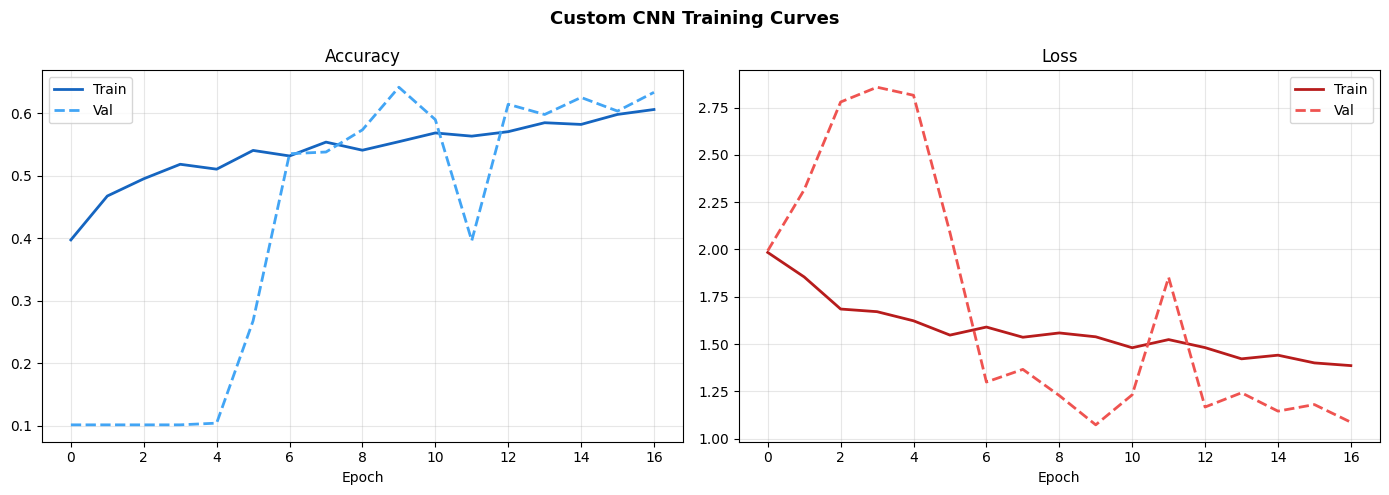

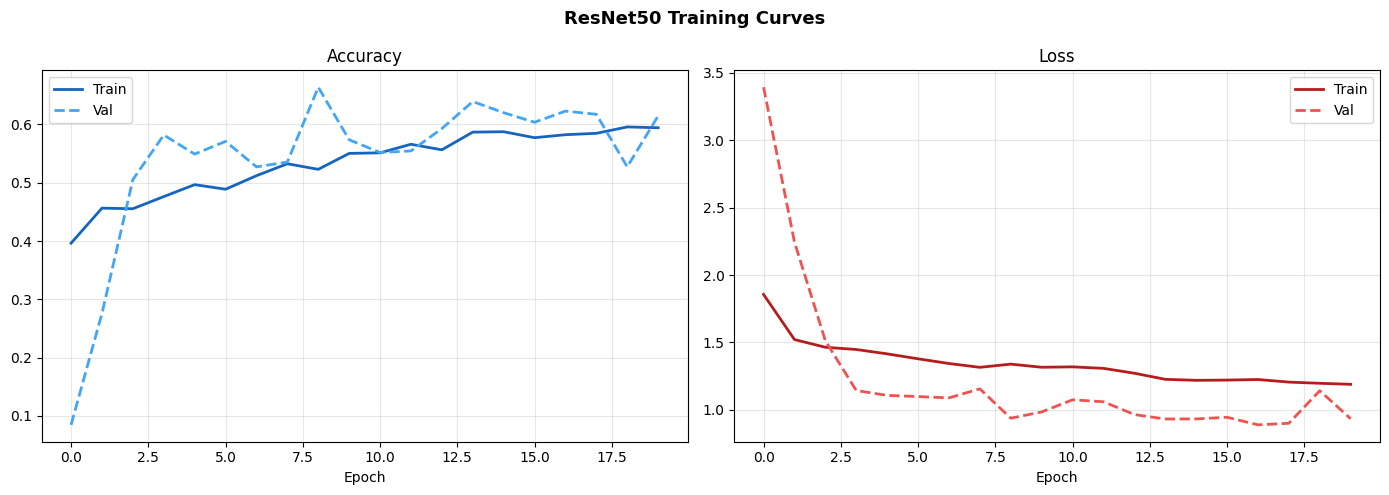

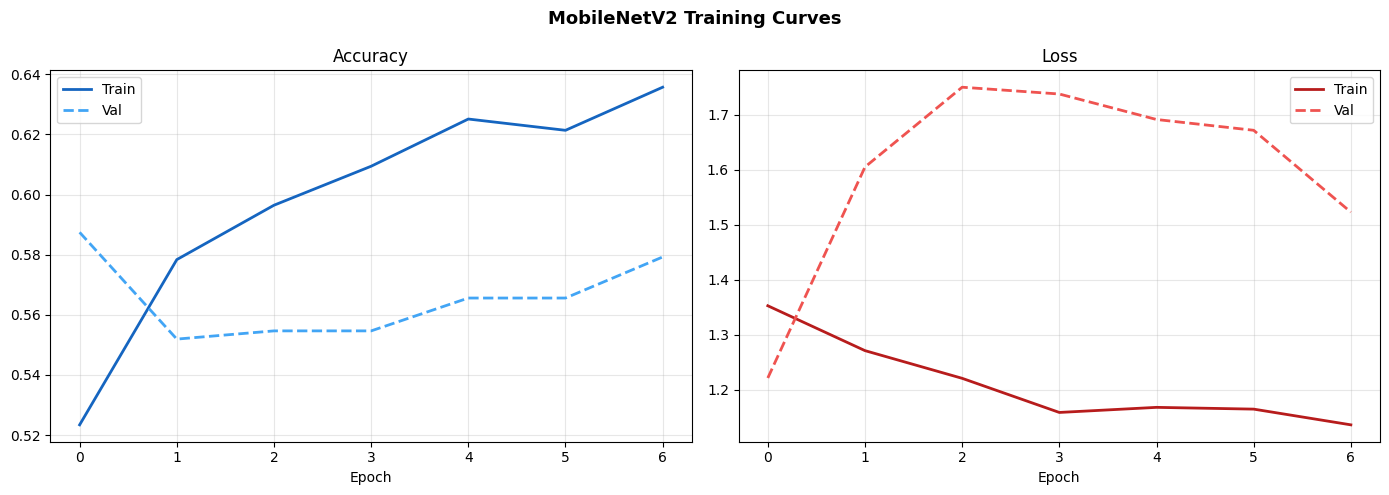

Training curves saved


In [9]:
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    ax1.plot(history.history['accuracy'], label='Train', color='#1565C0', lw=2)
    ax1.plot(history.history['val_accuracy'], label='Val', color='#42A5F5', lw=2, linestyle='--')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history.history['loss'], label='Train', color='#B71C1C', lw=2)
    ax2.plot(history.history['val_loss'], label='Val', color='#EF5350', lw=2, linestyle='--')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

plot_history(history_cnn, 'Custom CNN Training Curves',  os.path.join(FIGURES_DIR, 'fig4a_cnn_curves.pdf'))
plot_history(history_res, 'ResNet50 Training Curves',    os.path.join(FIGURES_DIR, 'fig4b_resnet_curves.pdf'))
plot_history(history_mn,  'MobileNetV2 Training Curves', os.path.join(FIGURES_DIR, 'fig4c_mobilenet_curves.pdf'))
print('Training curves saved')

## 10. Confusion Matrices

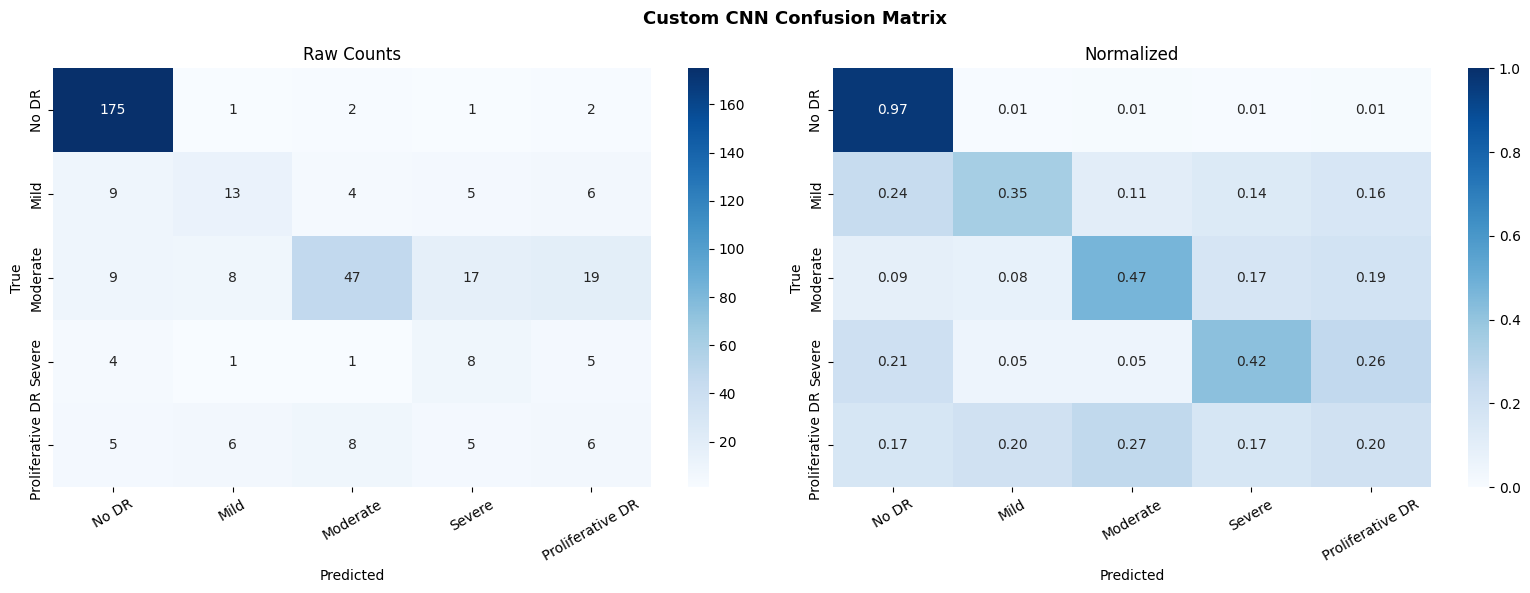

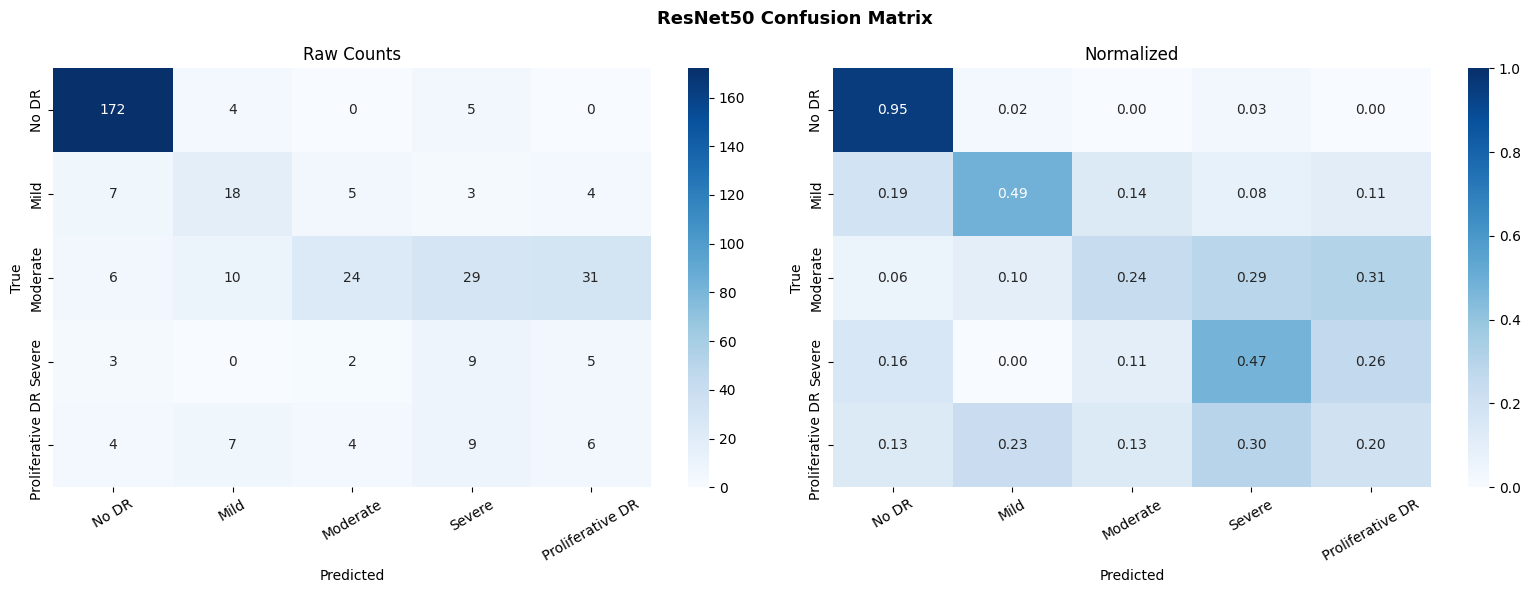

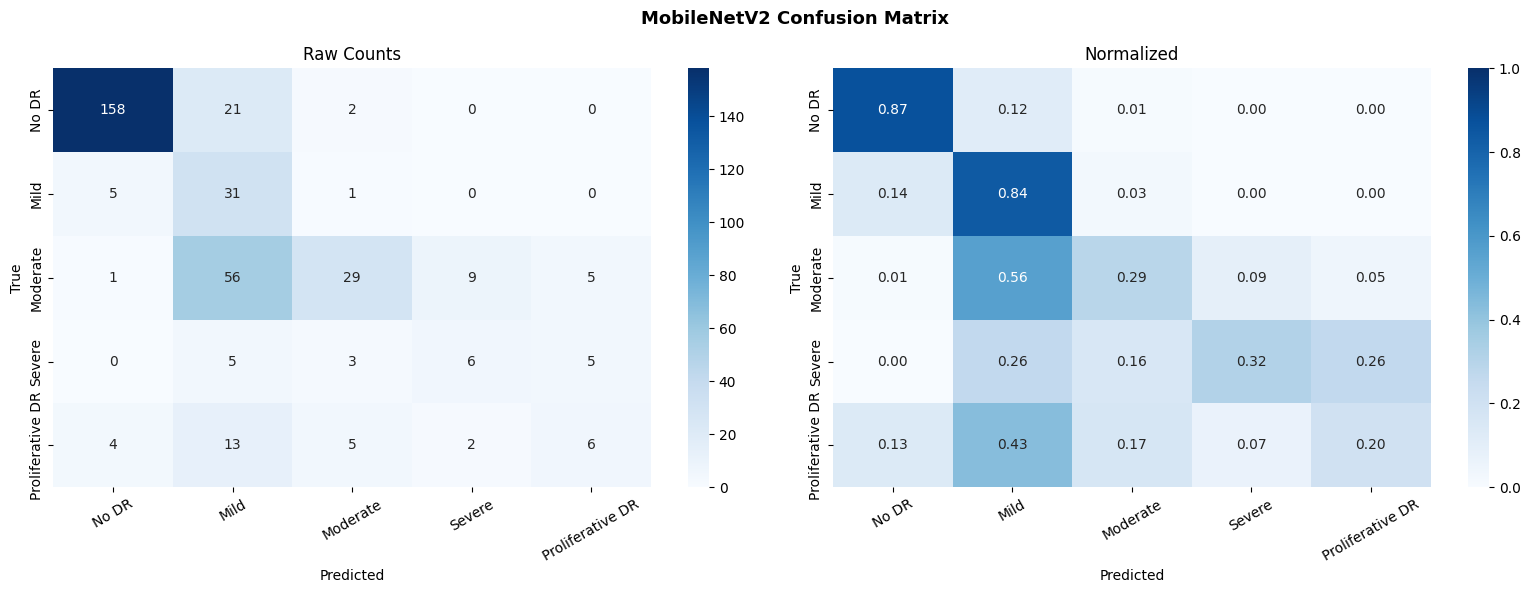

Confusion matrices saved


In [10]:
def plot_cm(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2, vmin=0, vmax=1)
    ax1.set_title('Raw Counts'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
    ax2.set_title('Normalized'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
    for a in [ax1, ax2]: a.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

plot_cm(results_cnn['y_true'], results_cnn['y_pred'], 'Custom CNN Confusion Matrix',   os.path.join(FIGURES_DIR, 'fig6a_cm_cnn.pdf'))
plot_cm(results_res['y_true'], results_res['y_pred'], 'ResNet50 Confusion Matrix',     os.path.join(FIGURES_DIR, 'fig6b_cm_resnet.pdf'))
plot_cm(results_mn['y_true'],  results_mn['y_pred'],  'MobileNetV2 Confusion Matrix',  os.path.join(FIGURES_DIR, 'fig6c_cm_mobilenet.pdf'))
print('Confusion matrices saved')

## 11. ROC Curves

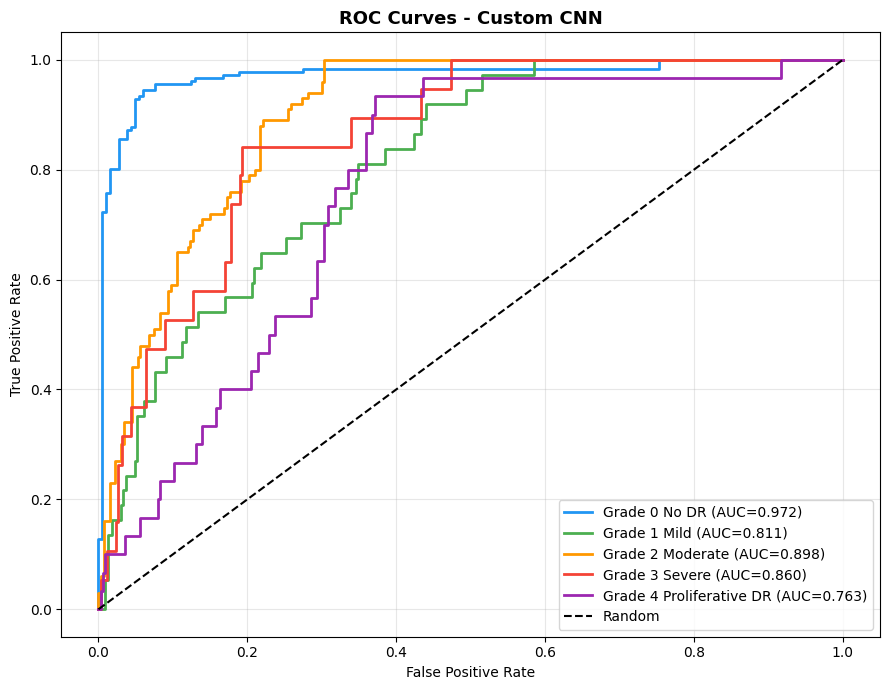

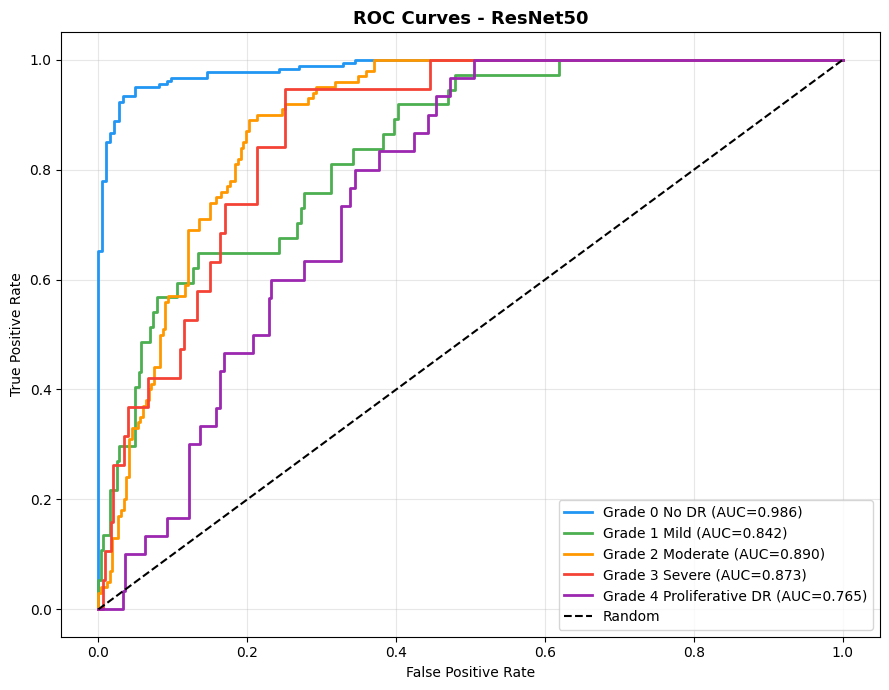

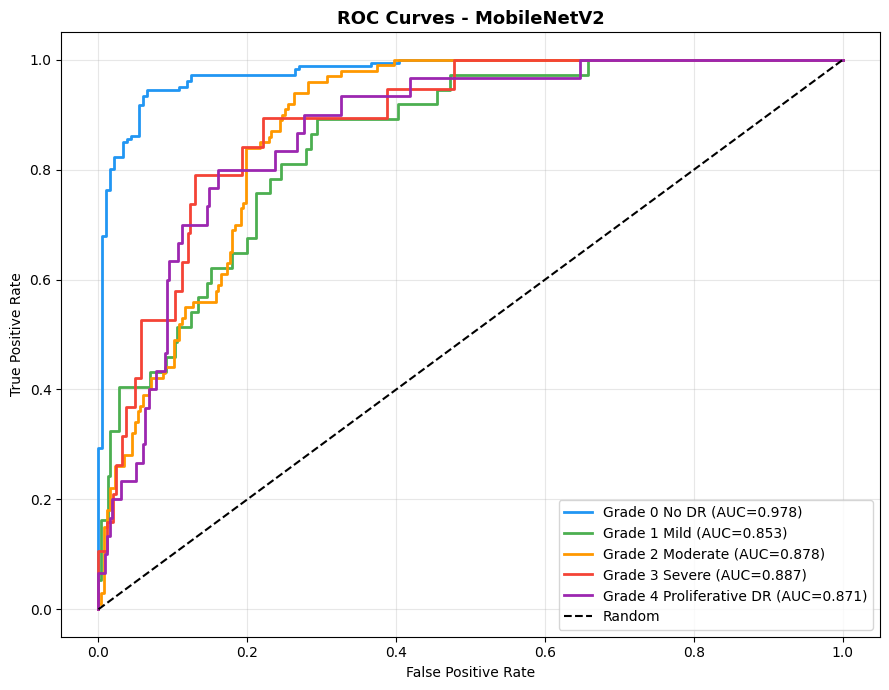

ROC curves saved


In [11]:
def plot_roc(y_true, y_pred_prob, model_name, save_path):
    y_bin = label_binarize(y_true, classes=CLASS_LABELS)
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
        ax.plot(fpr, tpr, color=color, lw=2, label=f'Grade {i} {name} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves - {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

plot_roc(results_cnn['y_true'], results_cnn['y_pred_prob'], 'Custom CNN',  os.path.join(FIGURES_DIR, 'fig7a_roc_cnn.pdf'))
plot_roc(results_res['y_true'], results_res['y_pred_prob'], 'ResNet50',    os.path.join(FIGURES_DIR, 'fig7b_roc_resnet.pdf'))
plot_roc(results_mn['y_true'],  results_mn['y_pred_prob'],  'MobileNetV2', os.path.join(FIGURES_DIR, 'fig7c_roc_mobilenet.pdf'))
print('ROC curves saved')

## 12. Model Comparison Table

Model Performance Comparison:
      Model Accuracy Quadratic WK Macro F1 Macro AUC
 Custom CNN   0.6785       0.6404   0.4711    0.8607
   ResNet50   0.6240       0.6709   0.4305    0.8711
MobileNetV2   0.6267       0.6647   0.4589    0.8935


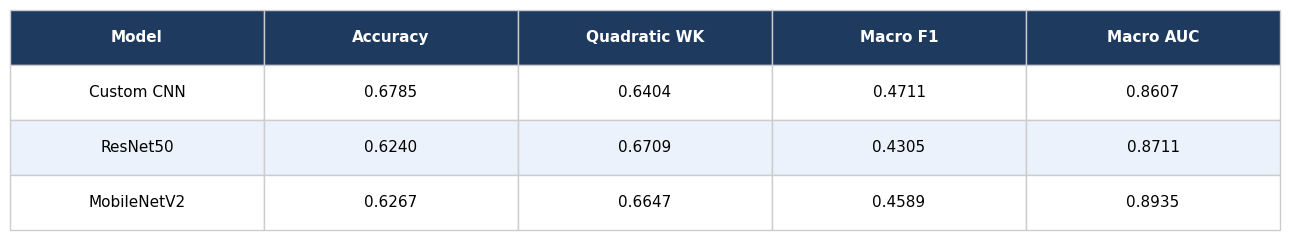

Comparison table saved


In [12]:
comparison_df = pd.DataFrame([{
    'Model': r['name'], 'Accuracy': f"{r['acc']:.4f}",
    'Quadratic WK': f"{r['qwk']:.4f}", 'Macro F1': f"{r['macro_f1']:.4f}",
    'Macro AUC': f"{r['auc']:.4f}",
} for r in all_results])

print('Model Performance Comparison:')
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(TABLES_DIR, 'table4_model_comparison.csv'), index=False)

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')
tbl = ax.table(cellText=comparison_df.values, colLabels=comparison_df.columns,
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#1E3A5F' if row==0 else '#EBF2FB' if row%2==0 else 'white')
    if row==0: cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#CCCCCC')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'table4_model_comparison.pdf'), dpi=150, bbox_inches='tight')
plt.show()
print('Comparison table saved')

## 13. Grad-CAM Visualizations

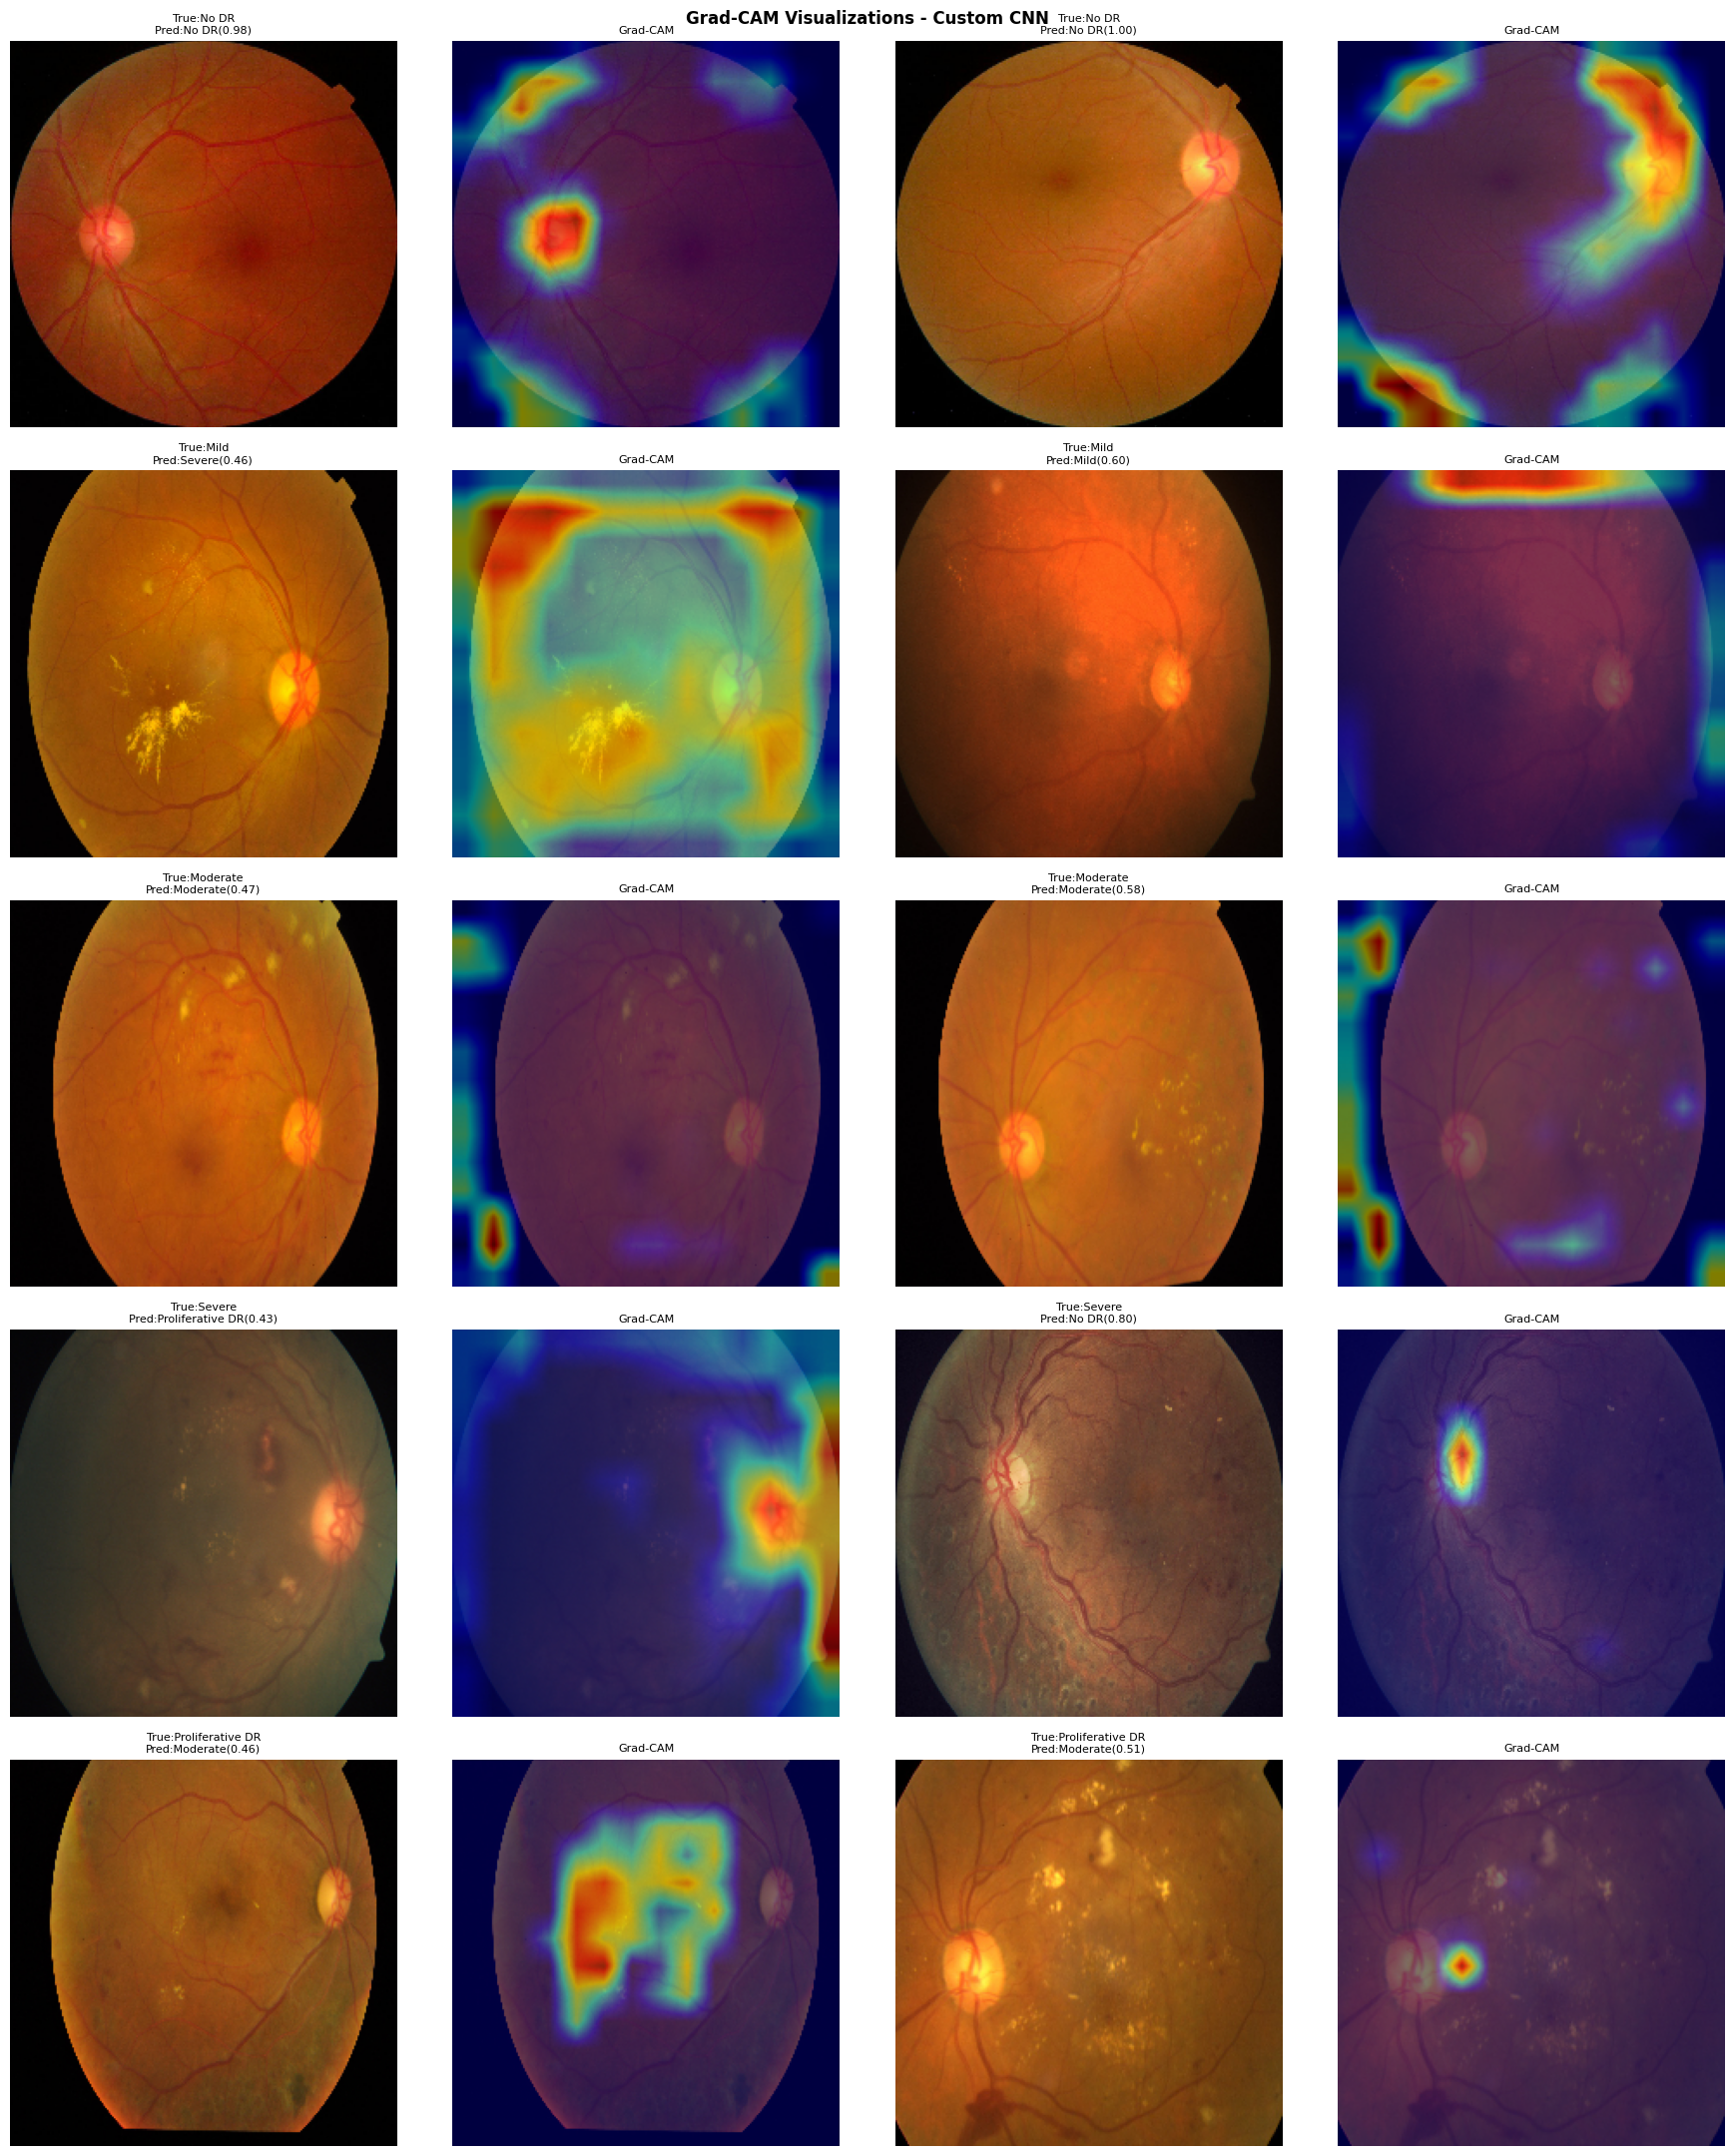

Grad-CAM saved


In [13]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(inputs=model.inputs,
                       outputs=[model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_idx = tf.argmax(preds[0])
        class_ch = preds[:, pred_idx]
    grads = tape.gradient(class_ch, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_idx), float(tf.reduce_max(preds).numpy())

def overlay_gradcam(img_path, heatmap, img_size=224):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    hm = cv2.resize(heatmap, (img_size, img_size))
    hm_color = cv2.cvtColor(cv2.applyColorMap((hm*255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return img, (img*0.5 + hm_color*0.5).astype(np.uint8)

def get_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name

last_conv_cnn = get_last_conv(custom_cnn)
fig, axes = plt.subplots(5, 4, figsize=(18, 22))
fig.suptitle('Grad-CAM Visualizations - Custom CNN', fontsize=12, fontweight='bold')
for grade in range(5):
    paths = test_df[test_df['diagnosis']==str(grade)]['filepath'].values[:2]
    for col_pair, img_path in enumerate(paths):
        img_arr = np.expand_dims(load_and_preprocess(img_path), 0)
        try:
            hm, pred_cls, conf = make_gradcam_heatmap(img_arr, custom_cnn, last_conv_cnn)
            orig, overlay = overlay_gradcam(img_path, hm)
            axes[grade, col_pair*2].imshow(orig)
            axes[grade, col_pair*2].set_title(f'True:{CLASS_NAMES[grade]}\nPred:{CLASS_NAMES[pred_cls]}({conf:.2f})', fontsize=8)
            axes[grade, col_pair*2].axis('off')
            axes[grade, col_pair*2+1].imshow(overlay)
            axes[grade, col_pair*2+1].set_title('Grad-CAM', fontsize=8)
            axes[grade, col_pair*2+1].axis('off')
        except Exception as e:
            print(f'Skipped grade {grade}, sample {col_pair}: {e}')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig8_gradcam.pdf'), dpi=130, bbox_inches='tight')
plt.show()
print('Grad-CAM saved')

## 14. Final Summary

In [14]:
print('=' * 60)
print('FINAL PROJECT SUMMARY')
print('=' * 60)
print(f'\nFigures (PDF) saved to: {FIGURES_DIR}')
for f in sorted(os.listdir(FIGURES_DIR)): print(f'  {f}')
print(f'\nTables (CSV) saved to: {TABLES_DIR}')
for f in sorted(os.listdir(TABLES_DIR)): print(f'  {f}')
print(f'\nModels saved to: {MODEL_DIR}')
for f in sorted(os.listdir(MODEL_DIR)): print(f'  {f}')
print('\nModel Performance:')
print(comparison_df.to_string(index=False))
best = comparison_df.loc[comparison_df['Quadratic WK'].astype(float).idxmax()]
print(f'\nBest model: {best["Model"]} (QWK = {best["Quadratic WK"]})')
print('\nProject complete!')

FINAL PROJECT SUMMARY

Figures (PDF) saved to: /kaggle/working/figures
  fig1_sample_images.pdf
  fig2_class_distribution.pdf
  fig3_preprocessing.pdf
  fig4a_cnn_curves.pdf
  fig4b_resnet_curves.pdf
  fig4c_mobilenet_curves.pdf
  fig6a_cm_cnn.pdf
  fig6b_cm_resnet.pdf
  fig6c_cm_mobilenet.pdf
  fig7a_roc_cnn.pdf
  fig7b_roc_resnet.pdf
  fig7c_roc_mobilenet.pdf
  fig8_gradcam.pdf
  table4_model_comparison.pdf

Tables (CSV) saved to: /kaggle/working/tables
  table1_class_distribution.csv
  table2_dataset_split.csv
  table3_report_Custom_CNN.csv
  table3_report_MobileNetV2.csv
  table3_report_ResNet50.csv
  table4_model_comparison.csv

Models saved to: /kaggle/working/models
  custom_cnn_best.keras
  mobilenetv2_best.keras
  resnet50_best.keras

Model Performance:
      Model Accuracy Quadratic WK Macro F1 Macro AUC
 Custom CNN   0.6785       0.6404   0.4711    0.8607
   ResNet50   0.6240       0.6709   0.4305    0.8711
MobileNetV2   0.6267       0.6647   0.4589    0.8935

Best model: Re

## 15. Gradio UI — Interactive DR Grading

In [15]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'gradio'], check=True)
import gradio as gr

CLASS_NAMES_UI = ['No DR (Grade 0)', 'Mild (Grade 1)', 'Moderate (Grade 2)',
                  'Severe (Grade 3)', 'Proliferative DR (Grade 4)']

def predict_dr(image):
    if image is None:
        return 'Please upload a retinal fundus image.'
    img = cv2.resize(image, (224, 224))
    img_array = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)
    pred_cnn = custom_cnn.predict(img_array, verbose=0)[0]
    pred_res = resnet_model.predict(img_array, verbose=0)[0]
    pred_mn  = mobilenet_model.predict(img_array, verbose=0)[0]
    ensemble = (pred_cnn + pred_res + pred_mn) / 3.0
    pred_cls = np.argmax(ensemble)
    confidence = ensemble[pred_cls] * 100
    result  = f'## DR Severity Prediction\n\n'
    result += f'### Result: **{CLASS_NAMES_UI[pred_cls]}**\n'
    result += f'**Confidence: {confidence:.1f}%**\n\n---\n\n'
    result += f'### Individual Models:\n'
    result += f'- Custom CNN: {CLASS_NAMES_UI[np.argmax(pred_cnn)]} ({pred_cnn[np.argmax(pred_cnn)]*100:.1f}%)\n'
    result += f'- ResNet50: {CLASS_NAMES_UI[np.argmax(pred_res)]} ({pred_res[np.argmax(pred_res)]*100:.1f}%)\n'
    result += f'- MobileNetV2: {CLASS_NAMES_UI[np.argmax(pred_mn)]} ({pred_mn[np.argmax(pred_mn)]*100:.1f}%)\n'
    return result

with gr.Blocks(title='DR Grading', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# Diabetic Retinopathy Severity Grading\nUpload a retinal fundus image to predict DR grade.')
    with gr.Row():
        image_input = gr.Image(label='Upload Eye Image', type='numpy', height=300)
        result_output = gr.Markdown()
    gr.Button('Predict DR Grade', variant='primary').click(
        fn=predict_dr, inputs=image_input, outputs=result_output)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a936ba3c38e1effe82.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
# Save All Figures & Tables + Create ZIP for Download

import os
import zipfile
import shutil

FIGURES_DIR = "/kaggle/working/figures"
TABLES_DIR  = "/kaggle/working/tables"
OUTPUT_ZIP  = "/kaggle/working/DR_Grading_Results.zip"

# ── List all saved figures ─────────────────────────────────
print("=" * 50)
print("FIGURES (PDF):")
print("=" * 50)
figures = sorted(os.listdir(FIGURES_DIR))
if figures:
    for f in figures:
        size = os.path.getsize(os.path.join(FIGURES_DIR, f))
        print(f"  ✓ {f} ({size/1024:.1f} KB)")
else:
    print("  No figures found!")

# ── List all saved tables ──────────────────────────────────
print("\n" + "=" * 50)
print("TABLES (CSV):")
print("=" * 50)
tables = sorted(os.listdir(TABLES_DIR))
if tables:
    for t in tables:
        size = os.path.getsize(os.path.join(TABLES_DIR, t))
        print(f"  ✓ {t} ({size/1024:.1f} KB)")
else:
    print("  No tables found!")

# ── Create ZIP with all figures + tables ───────────────────
print("\n" + "=" * 50)
print("Creating ZIP...")
print("=" * 50)

with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add all figures
    for f in figures:
        filepath = os.path.join(FIGURES_DIR, f)
        zipf.write(filepath, f"figures/{f}")
        print(f"  Added: figures/{f}")

    # Add all tables
    for t in tables:
        filepath = os.path.join(TABLES_DIR, t)
        zipf.write(filepath, f"tables/{t}")
        print(f"  Added: tables/{t}")

zip_size = os.path.getsize(OUTPUT_ZIP) / (1024*1024)
print(f"\n✓ ZIP created: DR_Grading_Results.zip ({zip_size:.1f} MB)")
print(f"  Location: {OUTPUT_ZIP}")
print("\nTo download:")
print("  Right panel → Output → /kaggle/working → DR_Grading_Results.zip → Download")

FIGURES (PDF):
  ✓ fig1_sample_images.pdf (939.1 KB)
  ✓ fig2_class_distribution.pdf (21.5 KB)
  ✓ fig3_preprocessing.pdf (2358.5 KB)
  ✓ fig4a_cnn_curves.pdf (19.2 KB)
  ✓ fig4b_resnet_curves.pdf (19.0 KB)
  ✓ fig4c_mobilenet_curves.pdf (19.4 KB)
  ✓ fig6a_cm_cnn.pdf (26.4 KB)
  ✓ fig6b_cm_resnet.pdf (27.5 KB)
  ✓ fig6c_cm_mobilenet.pdf (27.4 KB)
  ✓ fig7a_roc_cnn.pdf (22.8 KB)
  ✓ fig7b_roc_resnet.pdf (23.1 KB)
  ✓ fig7c_roc_mobilenet.pdf (24.1 KB)
  ✓ fig8_gradcam.pdf (3861.1 KB)
  ✓ table4_model_comparison.pdf (18.1 KB)

TABLES (CSV):
  ✓ table1_class_distribution.csv (0.1 KB)
  ✓ table2_dataset_split.csv (0.1 KB)
  ✓ table3_report_Custom_CNN.csv (0.6 KB)
  ✓ table3_report_MobileNetV2.csv (0.6 KB)
  ✓ table3_report_ResNet50.csv (0.6 KB)
  ✓ table4_model_comparison.csv (0.2 KB)

Creating ZIP...
  Added: figures/fig1_sample_images.pdf
  Added: figures/fig2_class_distribution.pdf
  Added: figures/fig3_preprocessing.pdf
  Added: figures/fig4a_cnn_curves.pdf
  Added: figures/fig4b_resne